## Autovectores, autovalores y matrices simétricas

### Método de la potencia

In [165]:
# Básicas

import numpy as np


def productoVector(A,v):
    m,n = A.shape
    nn = len(v)
    R = np.zeros(m)
    if n != nn:
        print('No se puede multiplicar')
        return None
    for i in range(m):
        R[i] = sum(A[i,:] * v)
    return(R)

def productoMatriz(A,B):
    m,n = A.shape
    mm,nn = B.shape
    if n != mm:
        print('No se pueden multiplicar')
        return None
    R = np.zeros((m,nn))
    for j in range(nn):
        R[:,j] = productoVector(A,B[:,j])
    return R

def traspuesta(A):
    m,n = A.shape
    R = np.zeros((n,m))
    for i in range(m):
        for j in range(n):
            R[j,i] = A[i,j]
    return R

def prod_int(x,y):
    r = 0
    if len(x) != len(y):
        print('Dimensiones distintas')
        return None
    for i in range(len(x)):
        r += x[i]*y[i]
    return(r)

def normaliza(x):
    return x / np.sqrt(prod_int(x,x))


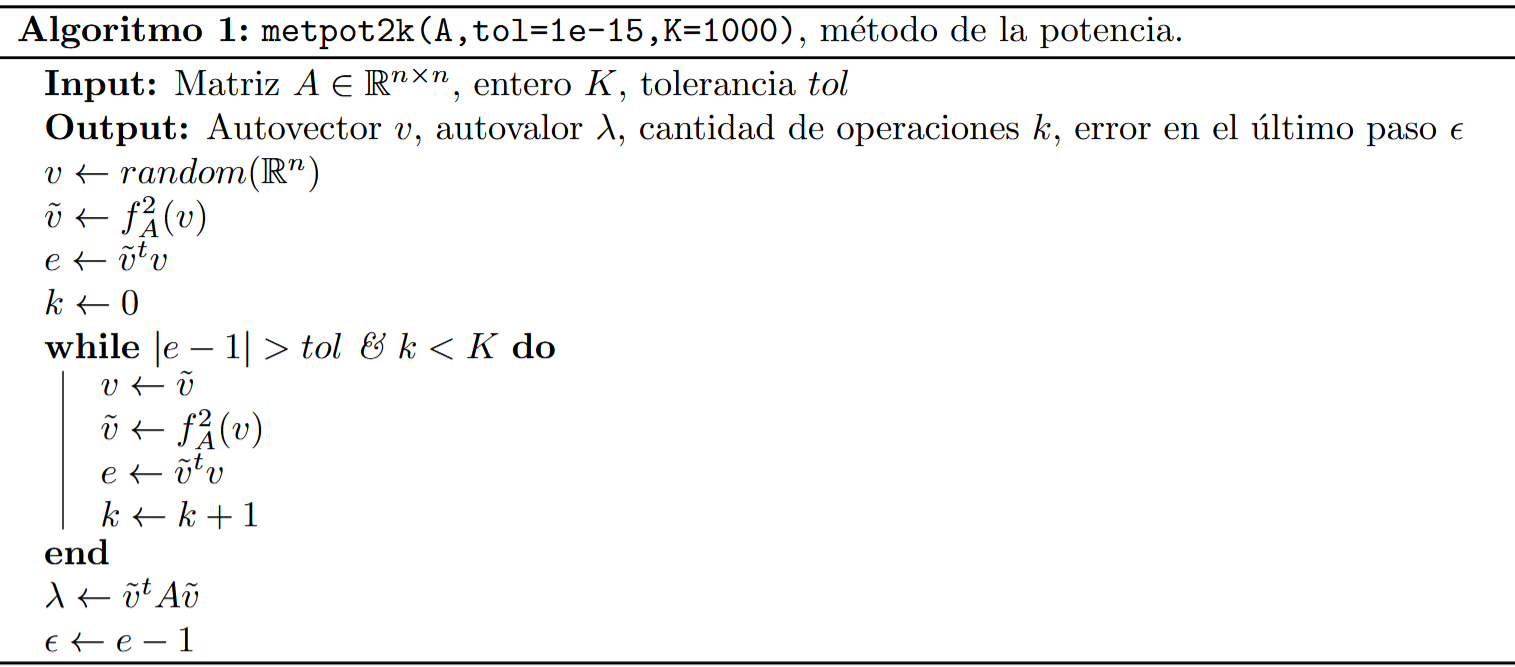

In [ ]:
# Método de la potencia (f2 style)

def f1(A,x):
    # A completar por ustedes

def f2(A,x):
    # A completar por ustedes

def metpot(A,tol=1e-15,K = 1e2):
    # A completar por ustedes



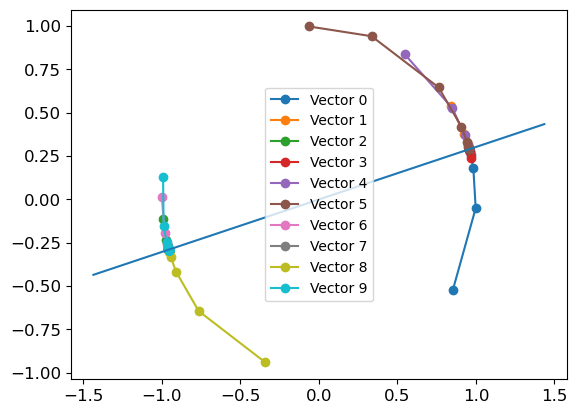

In [167]:
import matplotlib.pyplot as plt
A = np.array([[2,1],[1,-1]])
for i in range(10):
    x = np.random.random(2)-0.5
    x = normaliza(x)
    X = [x]
    for _ in range(50):
        x = f2(A,x)
        X.append(x)
    X = np.array(X).T
    plt.plot(X[0],X[1],'o-',label='Vector '+str(i))

v,l,_ = metpot(A)
plt.plot(v[0]*np.linspace(-1.5,1.5,2),v[1]*np.linspace(-1.5,1.5,2))
plt.legend()

### Diagonalización via Householder

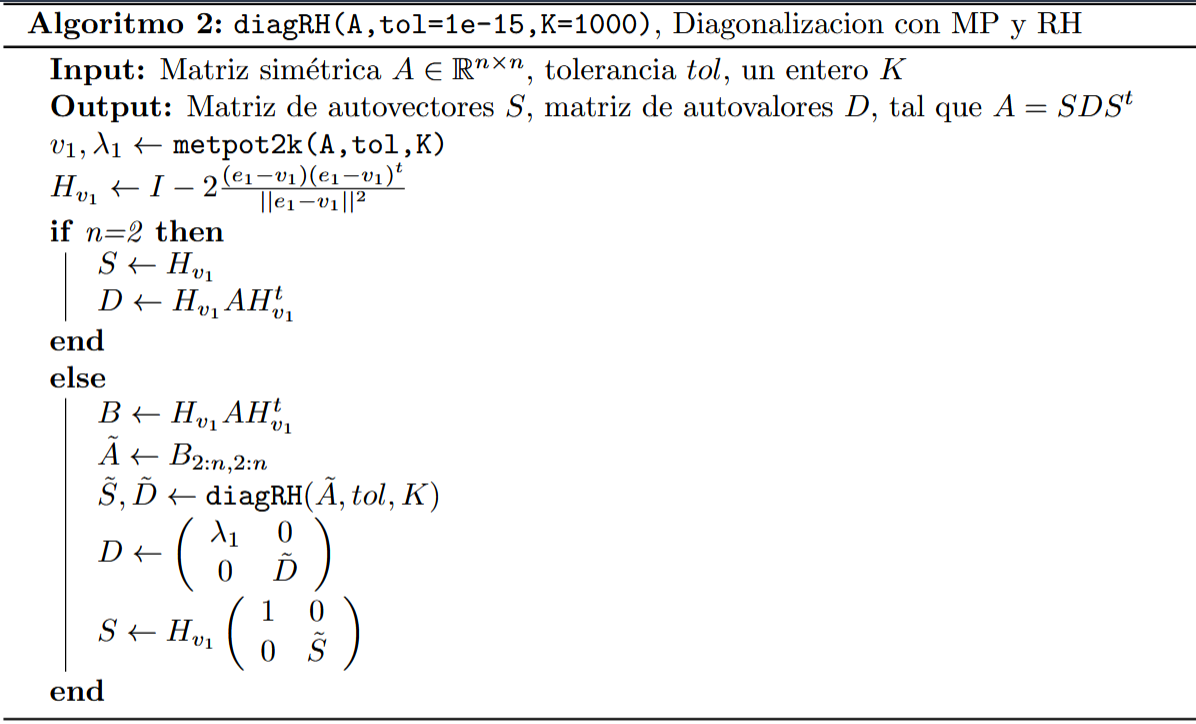

In [ ]:
# Diagonalizacion con Householder
def diagRH(A,tol=1e-15,K=1e4):
    # A completar por ustedes


### Testeo de error

In [169]:
S,D = diagRH(A,tol=1e-15)

print('Matriz A')
print(A)
print('Diagonalizacion')
print("S = ")
print(S)
print('D = ')
print(D)
print('¿Es S ortogonal?')
print(
    productoMatriz(S,traspuesta(S))
)
print('¿Recuperamos A?')
print(
    productoMatriz(S,productoMatriz(D,traspuesta(S)))
)

Matriz A
[[ 2  1]
 [ 1 -1]]
Diagonalizacion
S = 
[[ 0.95709202  0.28978416]
 [ 0.28978416 -0.95709202]]
D = 
[[ 2.30277564e+00  4.54826129e-08]
 [ 4.54826129e-08 -1.30277564e+00]]
¿Es S ortogonal?
[[1.00000000e+00 5.55111512e-17]
 [5.55111512e-17 1.00000000e+00]]
¿Recuperamos A?
[[ 2.  1.]
 [ 1. -1.]]


#### Funciones para testear

In [170]:
def simetricaAlAzar(n):
    A = np.random.random((n,n))
    A = productoMatriz(traspuesta(A),A)
    return(A)

def errorDiagonalizacion(A,tol=1e-15,Nrep=10):
    errorOrtogonal = 0
    errorDiagonal = 0
    errorA = 0
    errorPotencia = 0
    for _ in range(Nrep):
        S,D = diagRH(A,tol=tol)
        errorOrtogonal += np.abs( productoMatriz(traspuesta(S),S) - np.eye(A.shape[0]) ).sum()
        errorDiagonal += np.abs(np.tril(D,k=-1) + np.triu(D,k=1)).sum()
        errorA += np.abs(productoMatriz(S,productoMatriz(D,traspuesta(S)))-A).sum()
        errorPotencia += np.abs( productoMatriz(S,productoMatriz(D**10,traspuesta(S)))-np.linalg.matrix_power(A,10) ).sum()
    return([errorOrtogonal/Nrep,errorDiagonal/Nrep,errorA/Nrep,errorPotencia/Nrep])
    

##### Test en matriz de ejemplo

In [171]:
# Matriz A
A = np.array([[2,1],[1,-1]])
tolVec = [1e-8,1e-9,1e-10,1e-11,1e-12,1e-13,1e-14,1e-15]
eO = []
eD = []
eA = []
eP = []
for tol in tolVec:
    eOrt,eDiag,erA,ePote = errorDiagonalizacion(A,tol=tol,Nrep=30)
    eO.append(eOrt)
    eD.append(eDiag)
    eA.append(erA)
    eP.append(ePote)


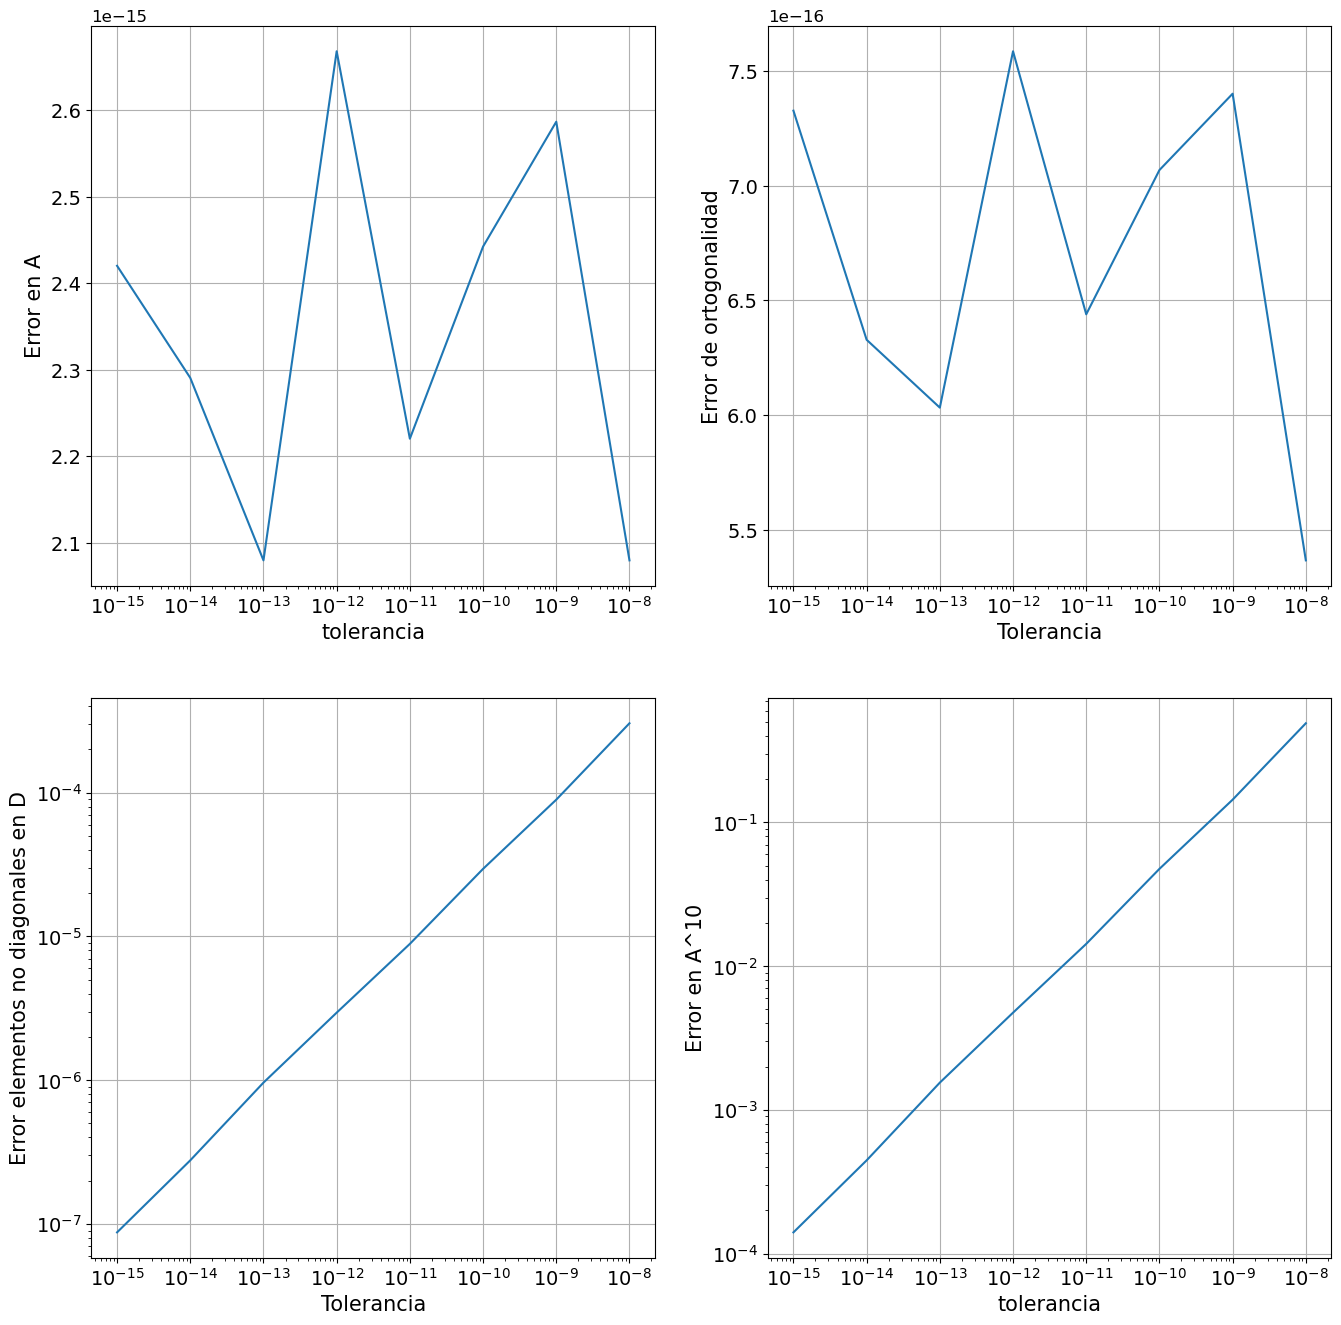

In [172]:
fig,axs = plt.subplots(figsize=(16,16),nrows=2,ncols=2)
# Error en A
axs[0,0].plot(tolVec,eA)
axs[0,0].set_xscale('log')
axs[0,0].set_xlabel('tolerancia',fontsize=15)
axs[0,0].set_ylabel('Error en A',fontsize=15)
axs[0,0].grid(True)
axs[0,0].tick_params(axis='x', labelsize=14) # For x-axis tick labels
axs[0,0].tick_params(axis='y', labelsize=14) # For y-axis tick labels

# Error de ortogonalidad
axs[0,1].plot(tolVec,eO)
axs[0,1].set_xscale('log')
axs[0,1].set_xlabel('Tolerancia',fontsize=15)
axs[0,1].set_ylabel('Error de ortogonalidad',fontsize=15)
axs[0,1].grid(True)
axs[0,1].tick_params(axis='x', labelsize=14) # For x-axis tick labels
axs[0,1].tick_params(axis='y', labelsize=14) # For y-axis tick labels

# Elementos no diagonales en D
axs[1,0].plot(tolVec,eD)
axs[1,0].set_xscale('log')
axs[1,0].set_yscale('log')
axs[1,0].set_xlabel('Tolerancia',fontsize=15)
axs[1,0].set_ylabel('Error elementos no diagonales en D',fontsize=15)
axs[1,0].grid(True)
axs[1,0].tick_params(axis='x', labelsize=14) # For x-axis tick labels
axs[1,0].tick_params(axis='y', labelsize=14) # For y-axis tick labels

# Error en potencia 10
axs[1,1].plot(tolVec,eP)
axs[1,1].set_xscale('log')
axs[1,1].set_yscale('log')
axs[1,1].set_xlabel('tolerancia',fontsize=15)
axs[1,1].set_ylabel('Error en A^10',fontsize=15)
axs[1,1].grid(True)
axs[1,1].tick_params(axis='x', labelsize=14) # For x-axis tick labels
axs[1,1].tick_params(axis='y', labelsize=14) # For y-axis tick labels


##### Test en matrices al azar

In [173]:
tolVec = [1e-8,1e-9,1e-10,1e-11,1e-12,1e-13,1e-14,1e-15]
n = 2
eO = []
eD = []
eA = []
eP = []
Nrep2 = 10
for tol in tolVec:
    eOP = 0
    eDP = 0
    eAP = 0
    ePP = 0
    for _ in range(Nrep2):
        A = simetricaAlAzar(n)
        eOrt,eDiag,erA, ePote = errorDiagonalizacion(A,tol=tol,Nrep=30)
        eOP += eOrt
        eDP += eDiag
        eAP += erA
        ePP += ePote
    eO.append(eOP/Nrep2)
    eD.append(eDP/Nrep2)
    eA.append(eAP/Nrep2)
    eP.append(ePP/Nrep2)

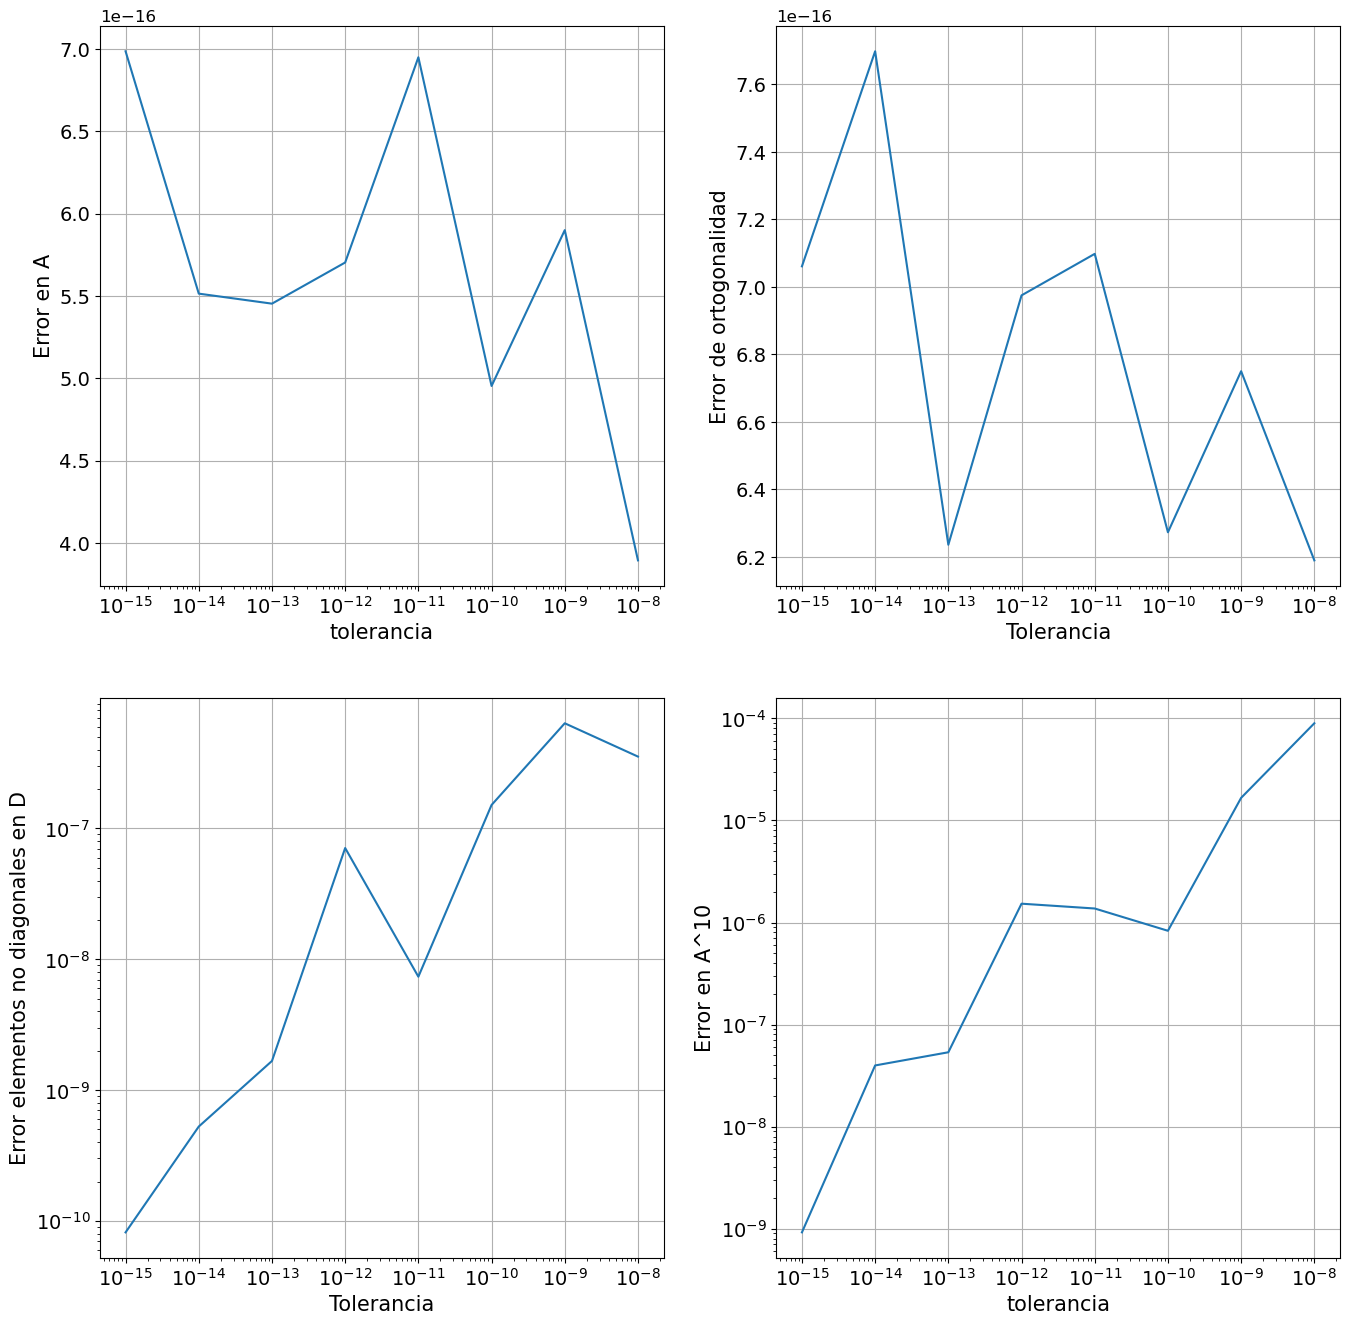

In [174]:
fig,axs = plt.subplots(figsize=(16,16),nrows=2,ncols=2)
# Error en A
axs[0,0].plot(tolVec,eA)
axs[0,0].set_xscale('log')
axs[0,0].set_xlabel('tolerancia',fontsize=15)
axs[0,0].set_ylabel('Error en A',fontsize=15)
axs[0,0].grid(True)
axs[0,0].tick_params(axis='x', labelsize=14) # For x-axis tick labels
axs[0,0].tick_params(axis='y', labelsize=14) # For y-axis tick labels

# Error de ortogonalidad
axs[0,1].plot(tolVec,eO)
axs[0,1].set_xscale('log')
axs[0,1].set_xlabel('Tolerancia',fontsize=15)
axs[0,1].set_ylabel('Error de ortogonalidad',fontsize=15)
axs[0,1].grid(True)
axs[0,1].tick_params(axis='x', labelsize=14) # For x-axis tick labels
axs[0,1].tick_params(axis='y', labelsize=14) # For y-axis tick labels

# Elementos no diagonales en D
axs[1,0].plot(tolVec,eD)
axs[1,0].set_xscale('log')
axs[1,0].set_yscale('log')
axs[1,0].set_xlabel('Tolerancia',fontsize=15)
axs[1,0].set_ylabel('Error elementos no diagonales en D',fontsize=15)
axs[1,0].grid(True)
axs[1,0].tick_params(axis='x', labelsize=14) # For x-axis tick labels
axs[1,0].tick_params(axis='y', labelsize=14) # For y-axis tick labels

# Error en potencia 10
axs[1,1].plot(tolVec,eP)
axs[1,1].set_xscale('log')
axs[1,1].set_yscale('log')
axs[1,1].set_xlabel('tolerancia',fontsize=15)
axs[1,1].set_ylabel('Error en A^10',fontsize=15)
axs[1,1].grid(True)
axs[1,1].tick_params(axis='x', labelsize=14) # For x-axis tick labels
axs[1,1].tick_params(axis='y', labelsize=14) # For y-axis tick labels


##### Test en función del $n$

In [175]:
tol= 1e-15
nVec = [2,4,8,16]
eO = []
eD = []
eA = []
eP = []
Nrep2 = 10
for n in nVec:
    eOP = 0
    eDP = 0
    eAP = 0
    ePP = 0
    for _ in range(Nrep2):
        A = simetricaAlAzar(n)
        eOrt,eDiag,erA,ePote = errorDiagonalizacion(A,tol=tol,Nrep=30)
        eOP += eOrt
        eDP += eDiag
        eAP += erA
        ePP += ePote
    eO.append(eOP/Nrep2)
    eD.append(eDP/Nrep2)
    eA.append(eAP/Nrep2)
    eP.append(ePP/Nrep2)


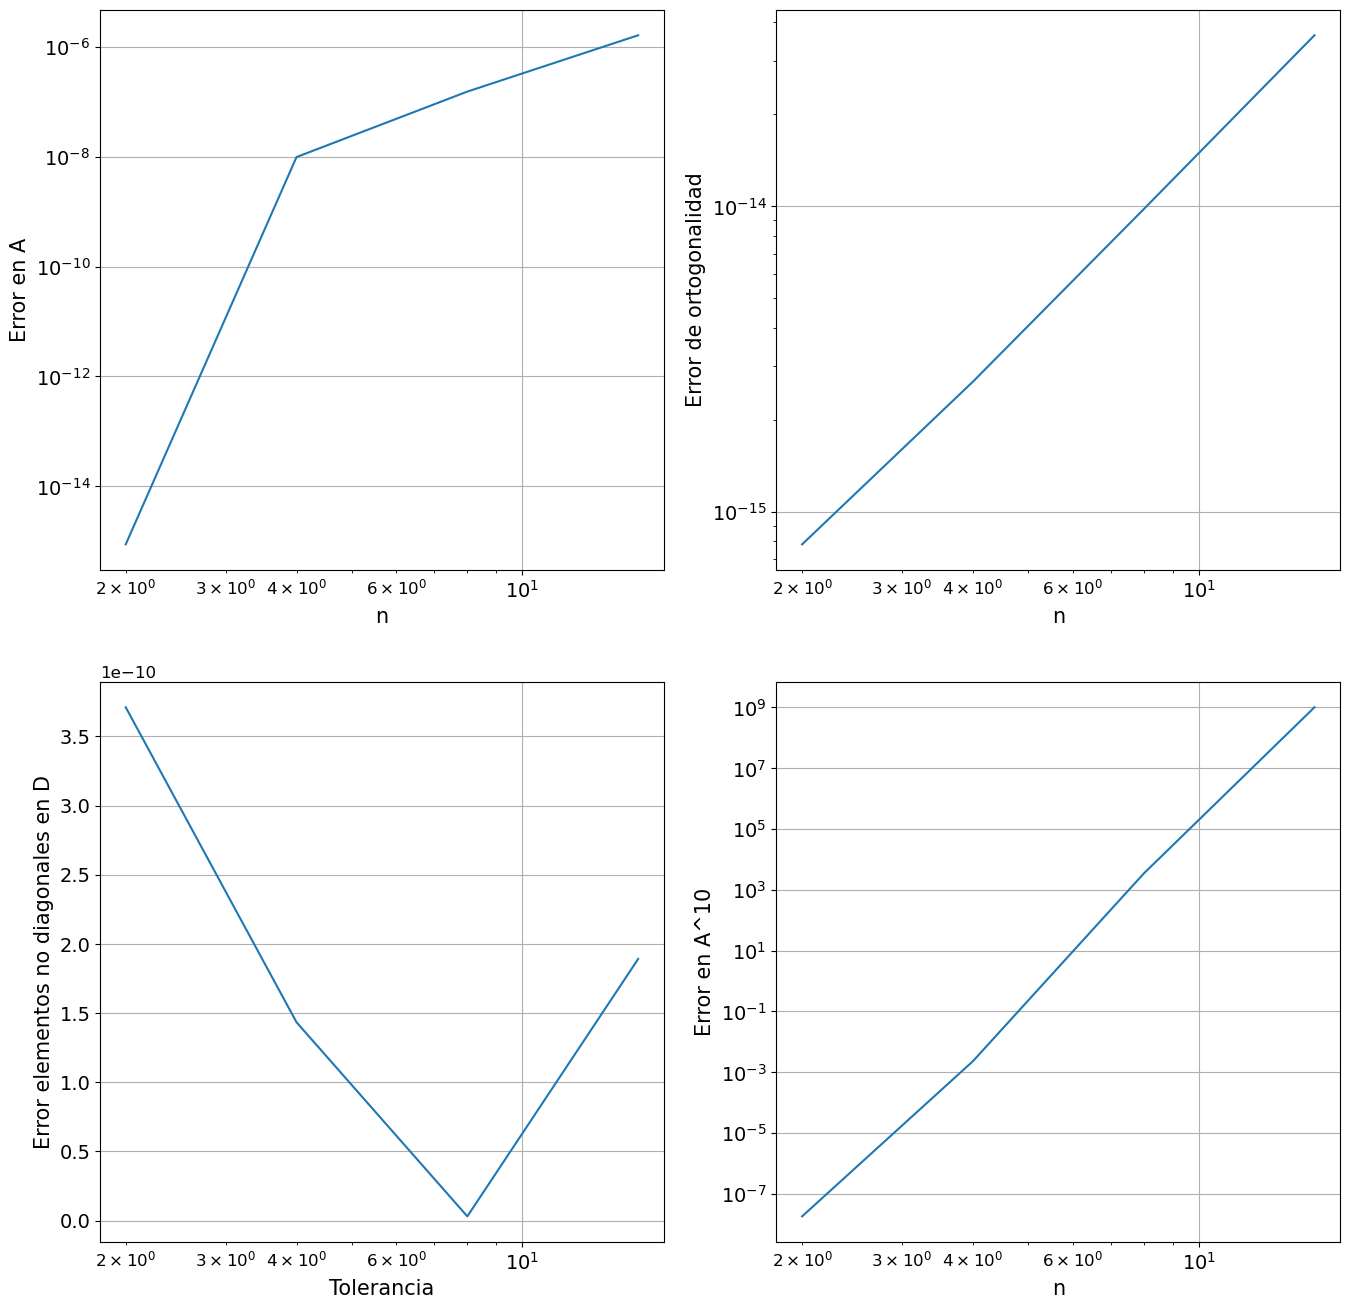

In [176]:
fig,axs = plt.subplots(figsize=(16,16),nrows=2,ncols=2)
# Error en A
axs[0,0].plot(nVec,eA)
axs[0,0].set_xlabel('n',fontsize=15)
axs[0,0].set_xscale('log')
axs[0,0].set_yscale('log')
axs[0,0].set_ylabel('Error en A',fontsize=15)
axs[0,0].grid(True)
axs[0,0].tick_params(axis='x', labelsize=14) # For x-axis tick labels
axs[0,0].tick_params(axis='y', labelsize=14) # For y-axis tick labels

# Error de ortogonalidad
axs[0,1].plot(nVec,eO)
axs[0,1].set_xlabel('n',fontsize=15)
axs[0,1].set_xscale('log')
axs[0,1].set_yscale('log')
axs[0,1].set_ylabel('Error de ortogonalidad',fontsize=15)
axs[0,1].grid(True)
axs[0,1].tick_params(axis='x', labelsize=14) # For x-axis tick labels
axs[0,1].tick_params(axis='y', labelsize=14) # For y-axis tick labels

# Elementos no diagonales en D
axs[1,0].plot(nVec,eD)
axs[1,0].set_xlabel('n',fontsize=15)
axs[1,0].set_xscale('log')
axs[1,0].set_xlabel('Tolerancia',fontsize=15)
axs[1,0].set_ylabel('Error elementos no diagonales en D',fontsize=15)
axs[1,0].grid(True)
axs[1,0].tick_params(axis='x', labelsize=14) # For x-axis tick labels
axs[1,0].tick_params(axis='y', labelsize=14) # For y-axis tick labels

# Error en potencia 10
axs[1,1].plot(nVec,eP)
axs[1,1].set_xlabel('n',fontsize=15)
axs[1,1].set_xscale('log')
axs[1,1].set_yscale('log')
axs[1,1].set_ylabel('Error en A^10',fontsize=15)
axs[1,1].grid(True)
axs[1,1].tick_params(axis='x', labelsize=14) # For x-axis tick labels
axs[1,1].tick_params(axis='y', labelsize=14) # For y-axis tick labels
